#*Practise from Lab Manual*

# **Graph**

In [ ]:
tree = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F', 'G'],
    'D': ['H'],
    'E': [],
    'F': ['I'],
    'G': [],
    'H': [],
    'I': []
}


# **BFS**

In [ ]:
def bfs(graph, start, goal):
  visited=[]
  queue=[start]
  if start==goal:
    return
  while queue:
    node=queue.pop(0)
    visited.append(node)
    print(node, end = " ")
    if (node==goal):
      print("\nGoal Found!")
      return True

    for neighbour in graph[node]:
      if neighbour not in queue:
        queue.append(neighbour)
  return False

# **Main**

In [ ]:
print("\nFollowing is the Breadth-First Search (BFS):")
bfs(tree, 'A', 'I')



Following is the Breadth-First Search (BFS):
A B C D E F G H I 
Goal Found!


True

# **Goal Based Agent based on bfs**

In [ ]:
class GoalBasedAgent:
  def __init__(self, goal):
    self.goal=goal

  def formulate_goal(self, percept):
    if percept==self.goal:
      return "Goal reached"
    return "Searching"

  def bfs_search(self, graph, start):
    visited=[]
    queue=[start]

    while queue:
      node=queue.pop(0)
      print("Visiting", node)
      if (node==self.goal):
        return f"Goal {self.goal} Reached"

      visited.append(node)
      for neighbour in graph[node]:
        if neighbour not in queue:
          queue.append(neighbour)
    return "Goal Not Found!"

  def act(self, percept, graph):
    goalStatus=self.formulate_goal(percept)
    if goalStatus=="Goal reached":
      return f"Goal {self.goal} Reached"
    else:
      return self.bfs_search(graph, percept)

class Environment:
  def __init__(self, graph):
    self.graph=graph

  def get_percept(self, node):
    return node

def run_agent(agent, environment, start_node):
  percept=environment.get_percept(start_node)
  action=agent.act(percept, environment.graph)
  print(action)

run_agent(GoalBasedAgent('I'), Environment(tree), 'A')

Visiting A
Visiting B
Visiting C
Visiting D
Visiting E
Visiting F
Visiting G
Visiting H
Visiting I
Goal I Reached


# **DFS**

In [ ]:
def DFS(graph, start, goal):
  visited=[]
  stack=[start]
  if start==goal:
    return
  while stack:
    node=stack.pop(0)
    visited.append(node)
    print(node, end = " ")
    if (node==goal):
      print("\nGoal Found!")
      return True
    temp=[]
    for neighbour in graph[node]:
      if neighbour not in visited:
        temp.insert(0,neighbour)
    for i in temp:          #go to left child first
      stack.insert(0,i)
  return False

DFS(tree, 'A', 'I')

A B D H E C F I 
Goal Found!


True

# **Depth Limited Search**

In [ ]:
# Graph without weights for DLS
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F', 'G'],
    'D': ['H'],
    'E': [],
    'F': ['I'],
    'G': [],
    'H': [],
    'I': []
}

# DLS Function
def dls(graph, start, goal, depth_limit):
    visited = []
    def dfs(node, depth):
        if depth > depth_limit:
            return None  # Limit reached
        visited.append(node)
        if node == goal:
            print(f"Goal found with DLS. Path: {visited}")
            return visited
        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                path = dfs(neighbor, depth + 1)
                if path:
                    return path
        visited.pop()  # Backtrack if goal not found
        return None

    return dfs(start, 0)

# Run DLS with depth limit 3
dls(graph, 'A', 'I', 3)


Goal found with DLS. Path: ['A', 'C', 'F', 'I']


['A', 'C', 'F', 'I']

---


# *Assignment 3*

---


# **Task 1:** Emergency Exit Finder

A building floor is represented as a grid:


```
building = [
[1, 1, 0, 1],
[0, 1, 1, 1],
[1, 1, 0, 1],
[1, 0, 1, 1]
]
```
Where
  - 1 = Walkable path,
  - 0 = Blocked path,


---


**Movement allowed:**
  - Up,
  - Down,
  - Left,
  - Right


---

- Start position: (0,0)
- Emergency Exit: (3,3)



---


**Requirements:**
1. Convert grid into graph (adjacency list).
2. Implement Breadth-First Search.
3. Print traversal order and shortest path.

In [ ]:
building = {
  (0, 0): [(1, 0)],
  (1, 0): [(0, 0), (1, 1)],
  (1, 1): [(1, 0), (2, 1), (1, 2)],
  (2, 1): [(1, 1), (3, 1)],
  (3, 1): [(2, 1), (3, 2), (3, 0)],
  (1, 2): [(1, 1), (0, 2)],
  (3, 2): [(3, 1), (3, 3)],
  (3, 0): [(3, 1)],
  (0, 2): [(1, 2), (0, 3)],
  (3, 3): [(3, 2), (2, 3)],
  (0, 3): [(0, 2)]
}

def bfs(building, start_pos, end_pos):
  visited=[]
  queue=[(start_pos, [start_pos])]

  while queue:
    node, path=queue.pop(0)
    print(f"Visiting node: {node}")
    visited.append(node)

    if node==end_pos:
      print("Goal Found!")
      return path

    for neighbour in building[node]:
      if neighbour not in queue and neighbour not in visited:
        new_path=list(path)
        new_path.append(neighbour)
        queue.append((neighbour, new_path))
  return []

start_node=(0,0)
end_node=(3,3)
print("Following is the Breadth-First Search (BFS):")
path=bfs(building, start_node, end_node)
if path!=[]:
  print("\nShortest Path")
  print(path)
else:
  print("Goal not found")

Following is the Breadth-First Search (BFS):
Visiting node: (0, 0)
Visiting node: (1, 0)
Visiting node: (1, 1)
Visiting node: (2, 1)
Visiting node: (1, 2)
Visiting node: (3, 1)
Visiting node: (0, 2)
Visiting node: (3, 2)
Visiting node: (3, 0)
Visiting node: (0, 3)
Visiting node: (3, 3)
Goal Found!

Shortest Path
[(0, 0), (1, 0), (1, 1), (2, 1), (3, 1), (3, 2), (3, 3)]


# **TASK 2:** Limited Energy Drone
Graph representation:


```
graph = {
'A': ['B', 'C'],
'B': ['D', 'E'],
'C': ['F'],
'D': ['G'],
'E': [],
'F': ['H'],
'G': [],
'H': []
}
```
- Start node: 'A'
- Goal node: 'H'
- Depth limit: 3

---

**Requirements:**
1. Implement Depth-Limited Search using recursion.
2. Add depth limit as parameter.
3. Show nodes visited and path if goal found.
4. Run with depth = 2 and depth = 3.

In [ ]:
graph = {
'A': ['B', 'C'],
'B': ['D', 'E'],
'C': ['F'],
'D': ['G'],
'E': [],
'F': ['H'],
'G': [],
'H': []
}

def dls(graph, start, goal, limit):
  visited=[]
  def dfs(node, depth):
    if depth>limit:
      return None
    print(f"Visiting {node}")
    visited.append(node)
    if (node==goal):
      return visited
    for neighbour in graph[node]:
      if neighbour not in visited:
        path=dfs(neighbour, depth+1)
        if path:
          return path
    visited.pop()
    return None
  return dfs(start, 0)

print("DLS with Depth 2")
path=dls(graph, 'A', 'H', 2)
if path!=None:
  print(f"Path: {path}")
else:
  print("Goal not found")

print("\nDLS with Depth 3")
path=dls(graph, 'A', 'H', 3)
if path!=None:
  print(f"Path: {path}")
else:
  print("Goal not found")

DLS with Depth 2
Visiting A
Visiting B
Visiting D
Visiting E
Visiting C
Visiting F
Goal not found

DLS with Depth 3
Visiting A
Visiting B
Visiting D
Visiting G
Visiting E
Visiting C
Visiting F
Visiting H
Path: ['A', 'C', 'F', 'H']


# **TASK 3:** Treasure Hunt
Use the same graph as Task 2.
- Start node: 'A'
- Goal node: 'G'


---


**Requirements:**
1. Implement Iterative Deepening Search.
2. Show each depth level clearly.
3. Print final path when goal is found.

In [ ]:
graph = {
'A': ['B', 'C'],
'B': ['D', 'E'],
'C': ['F'],
'D': ['G'],
'E': [],
'F': ['H'],
'G': [],
'H': []
}
def ids(graph, start, goal):
  def dls(limit):
    visited=[]
    def dfs(node, depth):
      if depth>limit:
        return None
      print(f"Visiting {node}")
      visited.append(node)
      if (node==goal):
        return visited
      for neighbour in graph[node]:
        if neighbour not in visited:
          path=dfs(neighbour, depth+1)
          if path:
            return path
      visited.pop()
      return None
    return dfs(start, 0)
  for depth in range(len(graph)):
    print(f"Searching with depth {depth}")
    path=dls(depth)
    if path!=None:
      print("Goal Found")
      return path
    print("Goal not found! Increasing depth limit\n")
  print("Max Depth reached! Goal not Found")
  return None

print("IDS")
path=ids(graph, 'A', 'G')
if path!=None:
  print(f"Path: {path}")

IDS
Searching with depth 0
Visiting A
Goal not found! Increasing depth limit

Searching with depth 1
Visiting A
Visiting B
Visiting C
Goal not found! Increasing depth limit

Searching with depth 2
Visiting A
Visiting B
Visiting D
Visiting E
Visiting C
Visiting F
Goal not found! Increasing depth limit

Searching with depth 3
Visiting A
Visiting B
Visiting D
Visiting G
Goal Found
Path: ['A', 'B', 'D', 'G']


#**TASK 4:** Delivery Route Optimization

Weighted graph:

```
graph = {
'S': {'A': 4, 'B': 2},
'A': {'C': 5, 'D': 10},
'B': {'E': 3},
'C': {'G': 4},
'D': {'G': 1},
'E': {'D': 4},
'G': {}
}
```
- Start node: 'S'
- Goal node: 'G'
---
**Requirements:**
1. Implement Uniform Cost Search.
2. Maintain frontier (priority-based), cost tracking, and path reconstruction.
3. Print least cost path and total cost.

In [ ]:
graph = {
'S': {'A': 4, 'B': 2},
'A': {'C': 5, 'D': 10},
'B': {'E': 3},
'C': {'G': 4},
'D': {'G': 1},
'E': {'D': 4},
'G': {}
}

def ucs(graph, start, goal):
  frontier=[(start, 0)]
  visited=set()
  cost_so_far={start:0}
  came_from={start:None}
  while frontier:
    frontier.sort(key=lambda x:x[1])
    curr_node, curr_cost = frontier.pop(0)
    if curr_node in visited:
      continue
    visited.add(curr_node)
    if curr_node==goal:
      path=[]
      while curr_node is not None:
        path.append(curr_node)
        curr_node=came_from[curr_node]
      path.reverse()
      print("Goal Found")
      print(f"Least Cost Path: {path}")
      print(f"Cost: {curr_cost}")
      return

    for neighbour, cost in graph[curr_node].items():
      new_cost=curr_cost+cost
      if neighbour not in cost_so_far or new_cost<cost_so_far[neighbour]:
        cost_so_far[neighbour]=new_cost
        came_from[neighbour]=curr_node
        frontier.append((neighbour, new_cost))
  print("Goal not found")

ucs(graph, 'S', 'G')

Goal Found
Least Cost Path: ['S', 'B', 'E', 'D', 'G']
Cost: 10


#**TASK 5:** Enhanced Maze Navigation with Multiple Goals
**Description:** Modify the given Best-First Search to find a path through a maze with multiple goal points. <br><br>The algorithm should visit all goal points and return
the shortest path covering all goals.
<br><br>
**Challenge:** The maze will have several
dead ends and multiple goal points at
different locations.
<br><br>
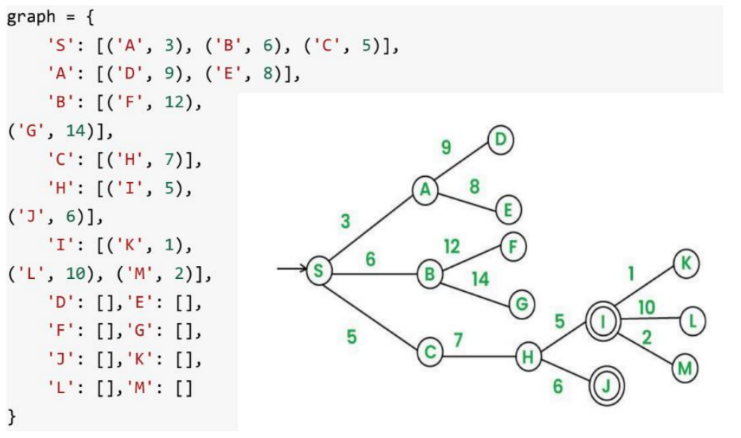

In [ ]:
from queue import PriorityQueue
graph={
  'S':[('A',3), ('B', 6), ('C', 5)],
  'A':[('D', 9), ('E', 8)],
  'B':[('F', 12), ('G', 14)],
  'C':[('H', 7)],
  'H':[('I', 5), ('J', 6)],
  'I':[('K', 1), ('L', 10), ('M', 2)],
  'D':[], 'E':[], 'F':[], 'G':[],
  'K':[], 'L':[], 'M':[], 'J':[]
}

def enhanced_bfs(graph, start, goals):
  def best_first_search(graph, start, goal):
    visited=set()
    pq= PriorityQueue()
    came_from={start:[]}
    cost_so_far={start:0}
    pq.put((0, start))
    while not pq.empty():
      cost, node = pq.get()
      path=list(came_from[node])
      cost+=cost_so_far[node]
      if node not in visited:
        print(f"Visiting {node}")
        visited.add(node)
        path.append(node)
        if node in goal:
          return cost, path, node
        for neighbor, weight in graph[node]:
          if neighbor not in visited:
            pq.put((weight, neighbor))
            came_from[neighbor]=path
            cost_so_far[neighbor]=cost
    return -1, [], ""
  tc, tp, goal=0, [], []
  print(f"Starting to search for goals: {goals}")
  for i in range(len(goals)):
    c, p, g=best_first_search(graph, start, goals)
    if i!=0 and len(p)>0:
      p.pop(0)
    if c != -1:
      print(f"Found goal {g}")
      goals.remove(g)
      goal.append(g)
      tc+=c
      tp+=p
      start=g
      print(f"\nSearching for remaining goals {goals}")
    else:
      print(f"Cannot find remaining goals\n")
  return tc, tp,goal

cost, path,goals=enhanced_bfs(graph, 'S', ['I','J'])
print("Final Result")
print(f"Goals found: {goals}")
print(f"Cost to reach goals: {cost}")
print(f"Path: {path}")

print("\n\nAnother test")
cost, path,goals=enhanced_bfs(graph, 'S', ['C','I'])
print("Final Result")
print(f"Goals found: {goals}")
print(f"Cost to reach goals: {cost}")
print(f"Path: {path}")


Starting to search for goals: ['I', 'J']
Visiting S
Visiting A
Visiting C
Visiting B
Visiting H
Visiting I
Found goal I

Searching for remaining goals ['J']
Visiting I
Visiting K
Visiting M
Visiting L
Cannot find remaining goals

Final Result
Goals found: ['I']
Cost to reach goals: 17
Path: ['S', 'C', 'H', 'I']


Another test
Starting to search for goals: ['C', 'I']
Visiting S
Visiting A
Visiting C
Found goal C

Searching for remaining goals ['I']
Visiting C
Visiting H
Visiting I
Found goal I

Searching for remaining goals []
Final Result
Goals found: ['C', 'I']
Cost to reach goals: 17
Path: ['S', 'C', 'H', 'I']


#**TASK 6:** A*

Implement an A* Search where the edge costs change dynamically at random intervals.<br><br>
The algorithm should adapt to these changes and always find the optimal path.
<br><br>Recompute and adjust paths in real time without restarting the algorithm from scratch.
<br><br>Randomly increase or decrease one edge cost.
<br><br>Example:
- A–B changes from 4 → 8
- B–E changes from 12 → 7
<br><br>
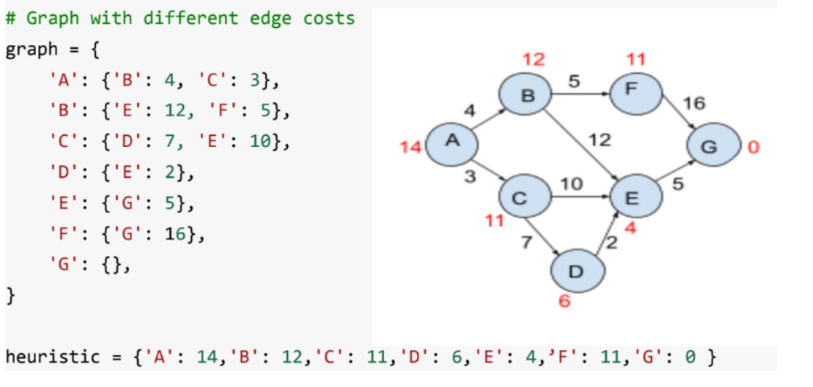

In [ ]:
import random
graph={
    'A': {'B':4, 'C':3},
    'B': {'E':12, 'F':5},
    'C': {'D':7, 'E':10},
    'D': {'E':2},
    'E': {'G':5},
    'F': {'G':16},
    'G': {},
}

heuristic={'A':14, 'B':12, 'C':11, 'D':6, 'E':4, 'F':11, 'G':0}

def dynamic_A_Star(graph, heuristic, start, goal):
  def A_star(start):
    frontier = [(start,(heuristic[start]+0))]
    visited=set()
    cost={start:0}
    came_from={start:None}

    while frontier:
      frontier.sort(key=lambda x:x[1])
      curr_node, curr_cost=frontier.pop(0)
      if curr_node in visited:
        continue
      visited.add(curr_node)
      if curr_node==goal:
        path=[]
        while curr_node!=None:
          path.append(curr_node)
          curr_node=came_from[curr_node]
        path.reverse()
        return path
      for neighbor in graph[curr_node]:
        new_cost=heuristic[curr_node]+graph[curr_node][neighbor]+cost[curr_node]
        if neighbor not in cost or new_cost<cost[neighbor]:
          cost[neighbor]=new_cost
          frontier.append((neighbor,(heuristic[neighbor]+new_cost)))
          came_from[neighbor]=curr_node
    return []
  interval=random.randint(min(1, len(graph)), max(2, int(len(graph)/2)))
  curr_node=start
  actual_path=[curr_node]
  i=1
  while curr_node!=goal:
    if i%interval==0:
      random_node = random.choice([n for n in graph.keys() if graph[n]])
      random_neighbor = random.choice(list(graph[random_node].keys()))
      random_change = random.randint(-(graph[random_node][random_neighbor]-1), graph[random_node][random_neighbor])
      print(f"\nChanging edge cost dynamically at random interval")
      print(f"Edge {random_node}->{random_neighbor} changed from {graph[random_node][random_neighbor]} to {graph[random_node][random_neighbor]+random_change}\n")
      graph[random_node][random_neighbor] += random_change
    path=A_star(curr_node)
    print(f"At {curr_node}, moving to {path[1]}, planned path: {path}")
    curr_node=path[1]
    actual_path+=curr_node
    i+=1
  print(f"\nFinal Path: {actual_path}")

print("A* Search\n")
dynamic_A_Star(graph, heuristic, 'A', 'G')

A* Search


Changing edge cost dynamically at random interval
Edge C->D changed from 7 to 5

At A, moving to C, planned path: ['A', 'C', 'E', 'G']

Changing edge cost dynamically at random interval
Edge F->G changed from 16 to 19

At C, moving to E, planned path: ['C', 'E', 'G']

Changing edge cost dynamically at random interval
Edge F->G changed from 19 to 31

At E, moving to G, planned path: ['E', 'G']

Final Path: ['A', 'C', 'E', 'G']
